In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns

## Exact P(HIGH) from the master equation

For the birth-death process with production rate $g(c) = p_0 + p\,c^3/(c^3+1)$
and degradation rate $d(n) = n$, the stationary distribution satisfies detailed balance:

$$P(n) \propto \prod_{k=1}^{n} \frac{\Omega \, g(k/\Omega)}{k}$$

No simulation needed — just a sum in log space.

In [54]:
def find_fixed_points(p0, p):
    if p <= 0:
        return np.array([p0])
    r = np.linspace(0, p0 + p + 2, 20000)
    f = p0 + p * r**3 / (r**3 + 1) - r
    fps = []
    for i in range(len(f) - 1):
        if f[i] * f[i+1] < 0:
            lo, hi = r[i], r[i+1]
            for _ in range(60):
                mid = (lo + hi) / 2
                fmid = p0 + p*mid**3/(mid**3+1) - mid
                flo  = p0 + p*lo**3/(lo**3+1) - lo
                if fmid * flo < 0: hi = mid
                else: lo = mid
            fps.append((lo + hi) / 2)
    return np.array(fps)


def compute_P_high(p0, p, Omega):
    """
    Exact P(HIGH) from the stationary distribution of the
    chemical master equation.  No simulation.
    
    log P(n) = sum_{k=1}^{n} [ log(Omega * g(k/Omega)) - log(k) ]
    """
    fps = find_fixed_points(p0, p)
    if len(fps) != 3:
        if len(fps) == 1:
            return 1.0 if fps[0] > 1.0 else 0.0
        return 0.0

    n_max = int((p0 + p + 5) * Omega)
    log_P = np.zeros(n_max + 1)
    for n in range(1, n_max + 1):
        c = n / Omega
        g = p0 + p * c**3 / (c**3 + 1.0)
        log_P[n] = log_P[n-1] + np.log(Omega * g) - np.log(n)

    P = np.exp(log_P)
    P = P/P.sum()

    n_unstable = int(fps[1] * Omega)
    return P[n_unstable+1:].sum()

---
## Parameters

In [55]:
# ============================================
#  CHANGE THESE
# ============================================

p0     = 0.2    # basal production
p_base = 3.0      # feedback strength at zero drugs
K_CHX  = 45.0     # CHX half-effect (nM)
K_CHL  = 450.0    # CHL half-effect (uM)
Omega  = 10.0       # system size (controls transition sharpness)

# Drug grid
CHX = np.linspace(0, 50, 3)      # nM, number of points = len
CHL = np.linspace(0, 1500, 6)    # uM

# p(CHX, CHL) = p_base * (1 + (CHX/K_CHX)^2) / (1 + CHL/K_CHL)

---
## Compute and plot

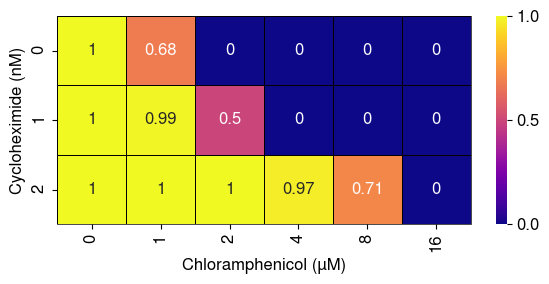

In [57]:
data = np.zeros((len(CHX), len(CHL)))
for i, chx in enumerate(CHX):
    for j, chl in enumerate(CHL):
        p = p_base * (1 + (chx / K_CHX)**2) / (1 + chl / K_CHL)
        data[i, j] = compute_P_high(p0, p, Omega)

# fig, ax = plt.subplots(figsize=(8, 5))
# im = ax.imshow(data, cmap='plasma', vmin=0, vmax=1, aspect='auto')

plt.rcParams['font.sans-serif'] = ['Nimbus Sans']
plt.rcParams['text.usetex'] = False  # Add this line

plt.rc('font',size=12)
plt.figure(figsize=(6,3))

# Custom cmap and norm as before
cmap = ListedColormap(['#0d0887', '#7201a8', '#f0f921'])
norm = BoundaryNorm([0.1, 0.25, 0.75, 2.0], cmap.N)

# Heatmap-style plot with black grid lines
sns.heatmap(
    data=data,
    cmap='plasma',
    cbar=True,
    linewidths=0.5,
    linecolor='black',
    square=False,
    xticklabels=False,
    yticklabels=False,
    annot=True
)

# Match tick locations and labels
plt.xticks([0.5,1.5,2.5,3.5,4.5,5.5], [0,1,2,4,8,16], rotation=90)
plt.yticks([0.5,1.5,2.5], [0,1,2], rotation=90)

plt.xlabel('Chloramphenicol (µM)')
plt.ylabel('Cycloheximide (nM)')

ax = plt.gca()
ax.patch.set_edgecolor('black')
ax.patch.set_linewidth(0.5)

# Colorbar tick labels to match your three states
cbar = ax.collections[0].colorbar
cbar.set_ticks([0, 0.5, 1])
# cbar.set_ticklabels(['Monostable OFF', 'Bistable', 'Monostable ON'])

plt.tight_layout()
plt.savefig('phase_diagram_simulations.png', dpi=1200)
plt.show()

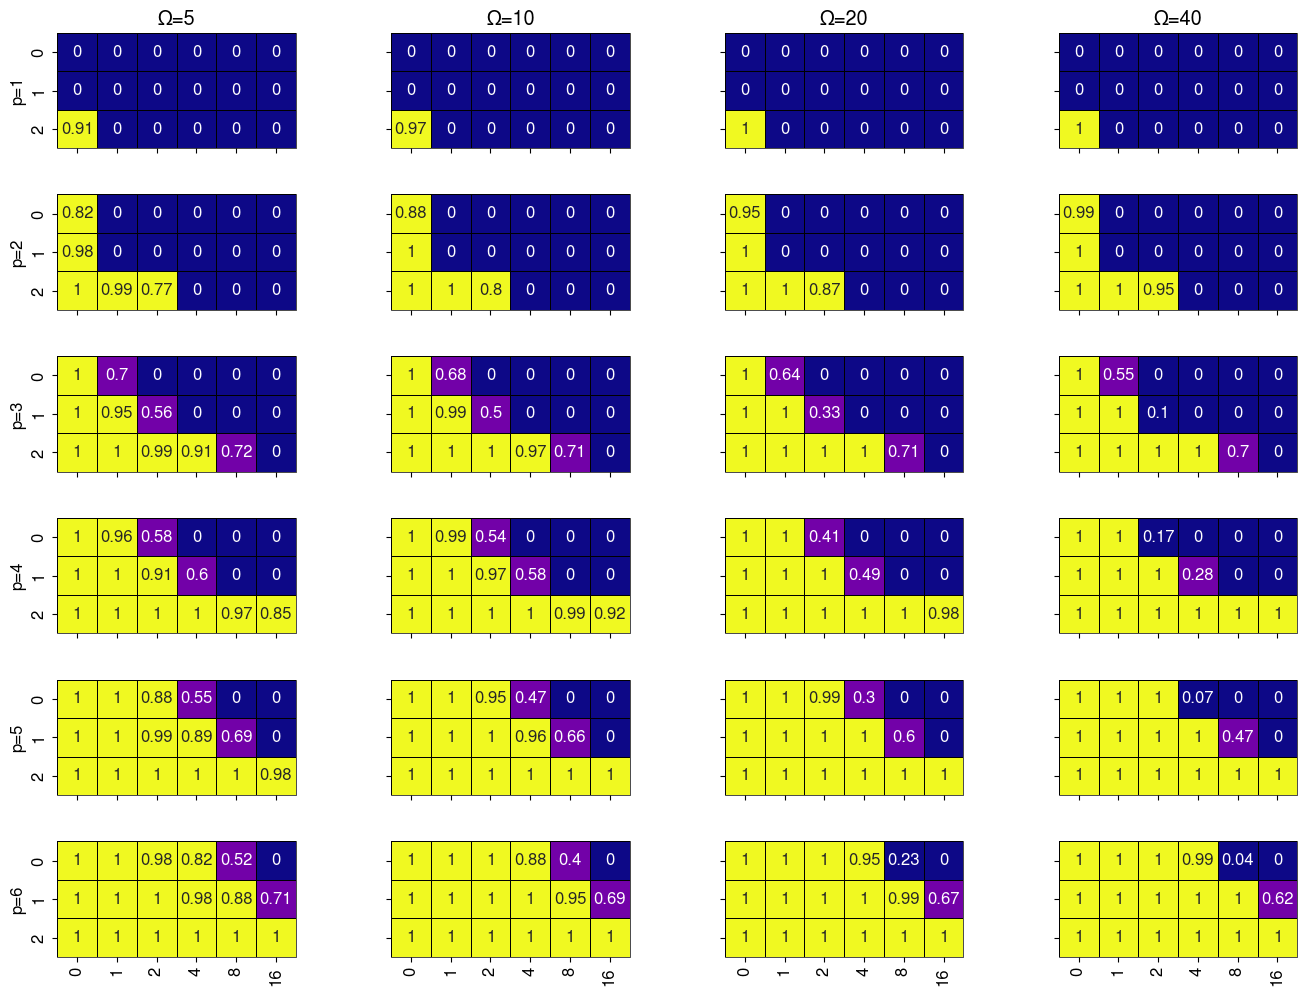

In [58]:
p_base_list = [1, 2, 3, 4, 5, 6]
Omega_list  = [5, 10, 20, 40]

plt.rcParams['font.sans-serif'] = ['Nimbus Sans']
plt.rcParams['text.usetex'] = False
plt.rc('font', size=12)

fig, axes = plt.subplots(
    nrows=len(p_base_list),
    ncols=len(Omega_list),
    figsize=(4*len(Omega_list), 2*len(p_base_list)),
    sharex=True,
    sharey=True
)

cmap = ListedColormap(['#0d0887', '#7201a8', '#f0f921'])
norm = BoundaryNorm([0.1, 0.25, 0.75, 2.0], cmap.N)

for r, p_base_val in enumerate(p_base_list):
    for c, Omega_val in enumerate(Omega_list):
        ax = axes[r, c]

        # compute data
        data = np.zeros((len(CHX), len(CHL)))
        for i, chx in enumerate(CHX):
            for j, chl in enumerate(CHL):
                p = p_base_val * (1 + (chx / K_CHX)**2) / (1 + chl / K_CHL)
                data[i, j] = compute_P_high(p0, p, Omega_val)

        data_rounded = np.round(data, 2)

        sns.heatmap(
            data=data_rounded,
            cmap=cmap,
            norm=norm,
            cbar=False,
            linewidths=0.5,
            linecolor='black',
            square=False,
            xticklabels=True,   # no x tick labels in panels
            yticklabels=True,    # allow y so we can set them
            annot=True,
            ax=ax
        )

        if r == 0:
            ax.set_title(f"Ω={Omega_val}")
        if c == 0:
            ax.set_ylabel(f"p={p_base_val}")

        # x ticks only on bottom row
        if r == len(p_base_list) - 1:
            ax.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5, 5.5])
            ax.set_xticklabels([0, 1, 2, 4, 8, 16], rotation=90)
        else:
            ax.set_xticks([])

        # y ticks only on left column
        # if c == 0:
        #     ax.set_yticks([0.5, 1.5, 2.5])
        #     ax.set_yticklabels([0, 1, 2], rotation=0)
        # else:
            # ax.set_yticks([])

        ax.patch.set_edgecolor('black')
        ax.patch.set_linewidth(0.5)

# shared colorbar outside
mappable = axes[0, 0].collections[0]
# cbar = fig.colorbar(
#     mappable,
#     ax=axes.ravel().tolist(),
#     shrink=0.6,
#     location='right',
#     pad=0.02
# )
# cbar.set_ticks([0.15, 0.5, 0.9])
# cbar.set_ticklabels(['Monostable OFF', 'Bistable', 'Monostable ON'])

plt.subplots_adjust(wspace=0.4, hspace=0.4)
plt.savefig('phase_diagram_subplots.png', dpi=1200)
plt.show()